In [3]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform 
import random
from sklearn.model_selection import KFold, cross_val_score
import re
import tldextract
from urllib.parse import urlparse
from collections import Counter
from scipy.stats import entropy

import warnings
warnings.filterwarnings("ignore") 

In [4]:
X = pd.read_csv('E:\Brave Downloads\SecureLink\data\phishing_site_urls.csv')

#Removing Unnecessary spaces
X['URL'].str.strip()

print(X)

                                                      URL Label
0       nobell.it/70ffb52d079109dca5664cce6f317373782/...   bad
1       www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...   bad
2       serviciosbys.com/paypal.cgi.bin.get-into.herf....   bad
3       mail.printakid.com/www.online.americanexpress....   bad
4       thewhiskeydregs.com/wp-content/themes/widescre...   bad
...                                                   ...   ...
549341                                    23.227.196.215/   bad
549342                                 apple-checker.org/   bad
549343                                  apple-iclods.org/   bad
549344                                 apple-uptoday.org/   bad
549345                                  apple-search.info   bad

[549346 rows x 2 columns]


In [5]:
special_df = pd.DataFrame()

special_chars = set() 

def find_special_char(x):
    special_chars_in_x = re.findall(r'[^a-zA-Z0-9]', x)
    special_chars.update(special_chars_in_x)
    return None

X_bad = X[X['Label'] == 'bad']
X_bad['URL'].apply(find_special_char)

special_chars = list(special_chars)

special_chars.remove('.')
special_chars.remove('/')

special_df['Special Character'] = special_chars
special_df['Frequency in bad URLs'] = special_df['Special Character'].apply(lambda x: X_bad[X_bad['URL'].str.contains(re.escape(x), regex=True)].shape[0])
special_df['Bad probability'] = special_df['Frequency in bad URLs']/special_df['Special Character'].apply(lambda x: X[X['URL'].str.contains(re.escape(x), regex=True)].shape[0])
special_df['Score'] = special_df['Bad probability']*special_df['Frequency in bad URLs'].apply(math.log)

special_df.sort_values(by='Score', ignore_index=True, ascending=False, inplace=True)
special_df


,Special Character,Frequency in bad URLs,Bad probability,Score
0,\,6363,0.966874,8.468132
1,;,11294,0.906639,8.460778
2,,1066,0.955197,6.659318
3,@,1809,0.882870,6.621990
4,',3591,0.774089,6.336839
...,...,...,...,...
167,Õ,1,0.047619,0.000000
168,ô,1,0.027778,0.000000
169,,1,0.043478,0.000000
170,,1,0.041667,0.000000


['\\', ';', ' ', '@', "'", ':', '&', '>', '<', '=']


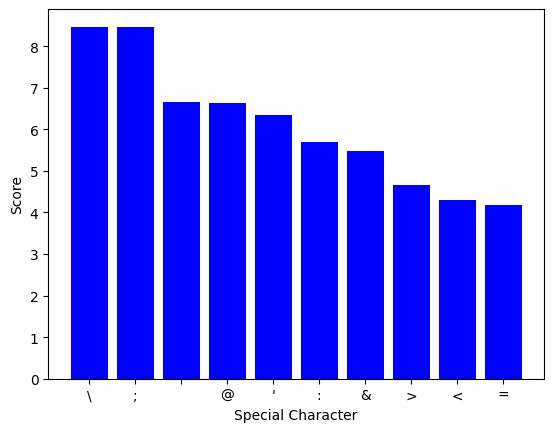

In [6]:
# only top ten are special characters

dangerous_chars = list(special_df['Special Character'].head(10))
print(dangerous_chars)
# colors = ['red', 'blue', 'green', 'purple', 'orange', 'pink', 'cyan', 'brown', 'yellow', 'magenta']
plt.bar(special_df['Special Character'].head(10), special_df['Score'].head(10), color = 'blue')
plt.xlabel('Special Character')
plt.ylabel('Score')
plt.show() 

In [7]:
TLD_df = pd.DataFrame()

TLD_list = pd.Series(X_bad['URL'].apply(lambda x: tldextract.extract(x).suffix)).unique()

TLD_df['TLD'] = TLD_list

TLD_df['Frequency in bad URLs'] = TLD_df['TLD'].apply(lambda x: X_bad[X_bad['URL'].str.contains(re.escape(x), regex=True)].shape[0])
TLD_df['Bad probability'] = TLD_df['Frequency in bad URLs']/TLD_df['TLD'].apply(lambda x: X[X['URL'].str.contains(re.escape(x), regex=True)].shape[0])
TLD_df['Score'] = TLD_df['Bad probability']*TLD_df['Frequency in bad URLs'].apply(math.log)

TLD_df.sort_values(by='Score', ignore_index=True, ascending=False, inplace=True)
TLD_df



,TLD,Frequency in bad URLs,Bad probability,Score
0,com.br,4235,0.982599,8.205817
1,mx,3698,0.931486,7.652669
2,cm,10508,0.812495,7.523618
3,bf,3900,0.878576,7.264711
4,date,5402,0.775258,6.662977
...,...,...,...,...
601,com.bb,1,1.000000,0.000000
602,sa.edu.au,1,0.142857,0.000000
603,gob.do,1,1.000000,0.000000
604,edu.bt,1,1.000000,0.000000


['com.br', 'mx', 'cm', 'bf', 'date', 'run', 'xyz', 'mg', 'com.ar', 'ph']


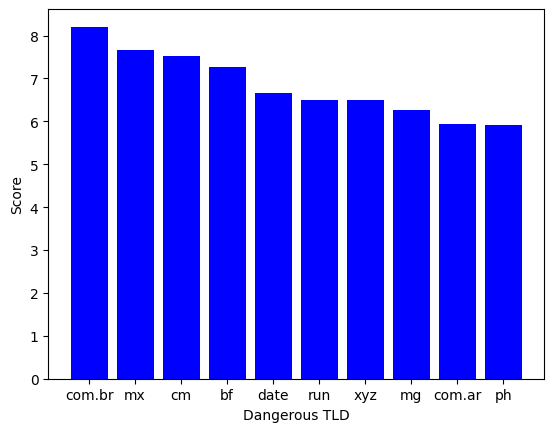

In [8]:
dangerous_TLDs = list(TLD_df['TLD'].head(10))
print(dangerous_TLDs)
plt.bar(TLD_df['TLD'].head(10), TLD_df['Score'].head(10), color = 'blue')
plt.xlabel('Dangerous TLD')
plt.ylabel('Score')
plt.show()

In [9]:
#1 URL length

X['URL length'] = X['URL'].apply(len)

#2 Numbers of dots

X['Number of dots'] = X['URL'].apply(lambda x: x.count('.'))

#3 Number of slashes

X['Number of slashes'] = X['URL'].apply(lambda x: x.count('/'))

#4 Percentage of numerical characters

X['Percentage of numerical characters'] = X['URL'].apply(lambda x: sum(c.isdigit() for c in x))/X['URL length']

#5 Dangerous characters

X['Dangerous characters'] = X['URL'].apply(lambda x: any(char in x for char in dangerous_chars))

#6 Dangerous TLD

X['Dangerous TLD'] = X['URL'].apply(lambda x: tldextract.extract(x).suffix in dangerous_TLDs)

#7 Entropy

def urlentropy(url):
    frequencies = Counter(url)
    prob = [frequencies[char] / len(url) for char in url]
    return entropy(prob, base=2)


X['Entropy'] = X['URL'].apply(urlentropy)

#8 IP Address

ip_pattern = r'[0-9]+(?:\.[0-9]+){3}'
X['IP Address'] = X['URL'].apply(lambda x: bool(re.search(ip_pattern, x)))

#9 Domain name length

X['Domain name length'] = X['URL'].apply(lambda x: len(tldextract.extract(x).domain))

#10 Suspicious keywords

sus_words = ['secure', 'account', 'update', 'login', 'verify' ,'signin', 'bank',
            'notify', 'click', 'inconvenient']

X['Suspicious keywords'] = X['URL'].apply(lambda x: sum([word in x for word in sus_words]) != 0)


#11 Repetitions

X['Repetitions'] = X['URL'].apply(lambda x: True if re.search(r'(.)\1{2,}', tldextract.extract(x).domain) else False)

#12 Redirections

def redirection(url):
  pos = url.rfind('//') #If the // is not found, it returns -1
  return pos>7

X['Redirections'] = X['URL'].apply(redirection)

In [10]:
label_counts = X.groupby('URL')['Label'].nunique()

conflicting_urls = label_counts[label_counts > 1]

print("Conflicting URLs:", len(conflicting_urls))

Conflicting URLs: 1


In [11]:
conflicting_url = conflicting_urls.index[0]  # conflicting data

print(X[X['URL'] == conflicting_url][['URL', 'Label']])

                        URL Label
248384  tommyhumphreys.com/  good
495286  tommyhumphreys.com/   bad
528161  tommyhumphreys.com/   bad


In [12]:
X = X[~X['URL'].isin(conflicting_urls.index)].copy() # removed conflicting url

In [13]:
X = X.drop_duplicates(subset=['URL']).reset_index(drop=True)   # removed duplicates

In [14]:
print(X[X['Label']=='bad'].shape[0]/X.shape[0])
print(X[X['Label']=='good'].shape[0]/X.shape[0])  # there is imbalanced data


0.22535361222727399
0.774646387772726


In [15]:
X['IP Address'] = X['IP Address'].astype(int)
X['Suspicious keywords'] = X['Suspicious keywords'].astype(int)
X['Repetitions'] = X['Repetitions'].astype(int)
X['Redirections'] = X['Redirections'].astype(int)
X['Dangerous characters'] = X['Dangerous characters'].astype(int)
X['Dangerous TLD'] = X['Dangerous TLD'].astype(int)
X['Label'] = (X['Label'] == 'bad').astype(int)

X.drop(columns=['URL'], inplace=True)

In [16]:
X.head()

,Label,URL length,Number of dots,Number of slashes,Percentage of numerical characters,Dangerous characters,Dangerous TLD,Entropy,IP Address,Domain name length,Suspicious keywords,Repetitions,Redirections
0,1,225,6,10,0.257778,1,0,7.667575,0,6,1,0,0
1,1,81,5,4,0.012346,1,0,6.190289,0,7,0,0,0
2,1,177,7,11,0.265537,0,0,7.288285,0,12,1,0,0
3,1,60,6,2,0.000000,0,0,5.786667,0,9,0,0,0
4,1,116,1,10,0.181034,0,0,6.611978,0,15,0,0,1


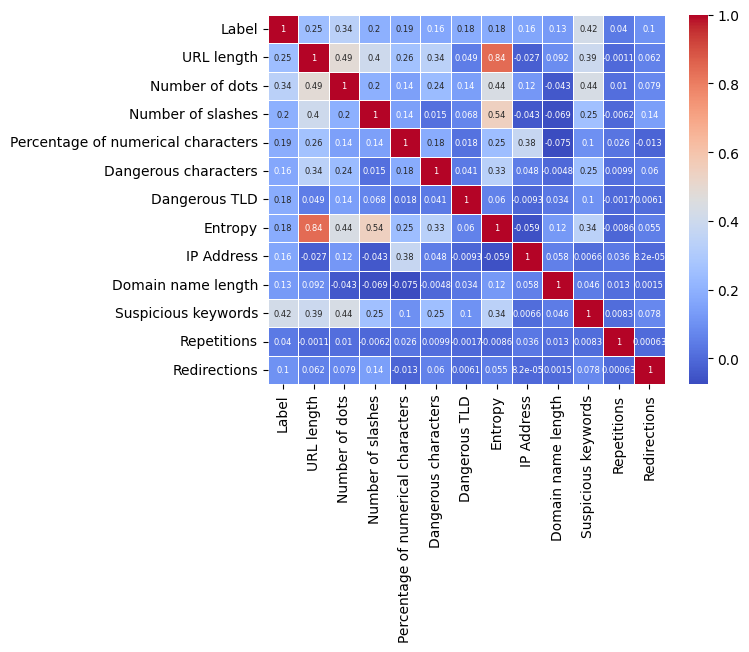

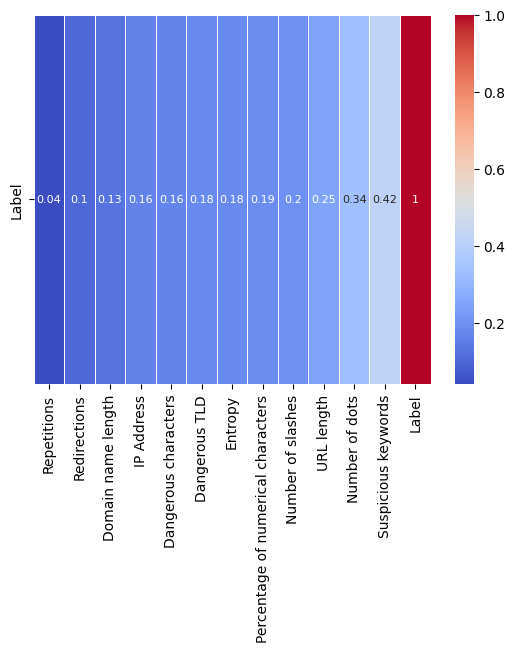

                                       Label
Repetitions                         0.040272
Redirections                        0.101308
Domain name length                  0.127908
IP Address                          0.161006
Dangerous characters                0.164952
Dangerous TLD                       0.181473
Entropy                             0.182032
Percentage of numerical characters  0.188359
Number of slashes                   0.197600
URL length                          0.246598
Number of dots                      0.336396
Suspicious keywords                 0.417664
Label                               1.000000


In [17]:
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, annot_kws={"size": 6})
plt.show()
sns.heatmap(corr_matrix[['Label']].sort_values(by='Label').T, annot=True, cmap='coolwarm', linewidths=0.5, annot_kws={"size": 8})
plt.show()
print(corr_matrix[['Label']].sort_values(by='Label')) 

In [18]:
y = X['Label']
X = X.drop('Label',axis=1)


In [41]:
X.to_csv('data/x.csv')

In [42]:
y.to_csv('data/y.csv')

In [19]:
X.head()

,URL length,Number of dots,Number of slashes,Percentage of numerical characters,Dangerous characters,Dangerous TLD,Entropy,IP Address,Domain name length,Suspicious keywords,Repetitions,Redirections
0,225,6,10,0.257778,1,0,7.667575,0,6,1,0,0
1,81,5,4,0.012346,1,0,6.190289,0,7,0,0,0
2,177,7,11,0.265537,0,0,7.288285,0,12,1,0,0
3,60,6,2,0.000000,0,0,5.786667,0,9,0,0,0
4,116,1,10,0.181034,0,0,6.611978,0,15,0,0,1


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)


In [21]:
print(X_train.shape)
print(X_test.shape)


(405755, 12)
(101439, 12)


In [ ]:
# to get a baseline which model to go with

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

# Stratified 3-fold cross-validation
kf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=22
)

# Metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# Models
models = [
    ('Decision Tree', DecisionTreeClassifier(random_state=22)),
    ('Random Forest', RandomForestClassifier(random_state=22)),
    ('AdaBoost', AdaBoostClassifier(random_state=22)),
    ('XGBoost', XGBClassifier(random_state=22))
]

# Store results
results = []

for name, model in models:

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring=scoring,
        n_jobs=-1
    )

    result = {
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean()
    }

    results.append(result)

    print(f"\n{name}")
    print("Accuracy :", result['Accuracy'])
    print("Precision:", result['Precision'])
    print("Recall   :", result['Recall'])
    print("F1       :", result['F1'])

In [35]:
kf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=22
)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# Calculate class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale Pos Weight:", scale_pos_weight)

models = [
    (
        'Random Forest',
        RandomForestClassifier(
            random_state=22,
            class_weight='balanced',
            n_jobs=-1
        )
    ),
    
    (
        'XGBoost',
        XGBClassifier(
            random_state=22,
            scale_pos_weight=scale_pos_weight,
            n_jobs=-1
        )
    )
]

results = []

for name, model in models:

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring=scoring,
        n_jobs=-1
    )

    result = {
        'Model': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1': scores['test_f1'].mean()
    }

    results.append(result)

    print(f"\n{name}")
    print(f"Accuracy : {result['Accuracy']:.4f}")
    print(f"Precision: {result['Precision']:.4f}")
    print(f"Recall   : {result['Recall']:.4f}")
    print(f"F1       : {result['F1']:.4f}")


# Comparison table
results_df = pd.DataFrame(results)

print("\nComparison:")
print(results_df)

Scale Pos Weight: 3.4233620407718304

Random Forest
Accuracy : 0.8916
Precision: 0.7869
Recall   : 0.7139
F1       : 0.7486

XGBoost
Accuracy : 0.8628
Precision: 0.6602
Recall   : 0.8104
F1       : 0.7276

Comparison:
           Model  Accuracy  Precision    Recall        F1
0  Random Forest  0.891605   0.786867  0.713900  0.748606
1        XGBoost  0.862826   0.660193  0.810367  0.727607



Random Forest
[[74161  4710]
 [ 6249 16319]]


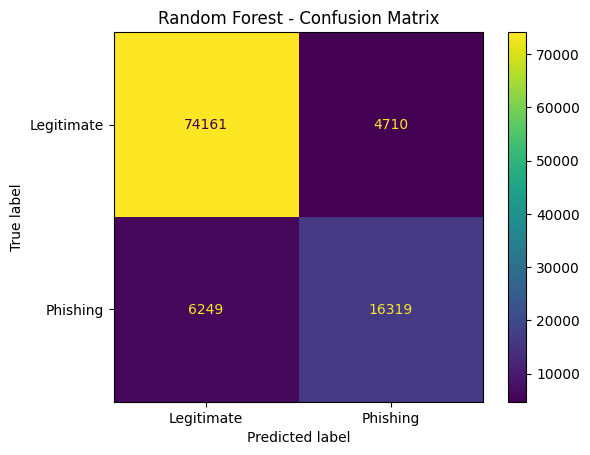


XGBoost
[[69207  9664]
 [ 4263 18305]]


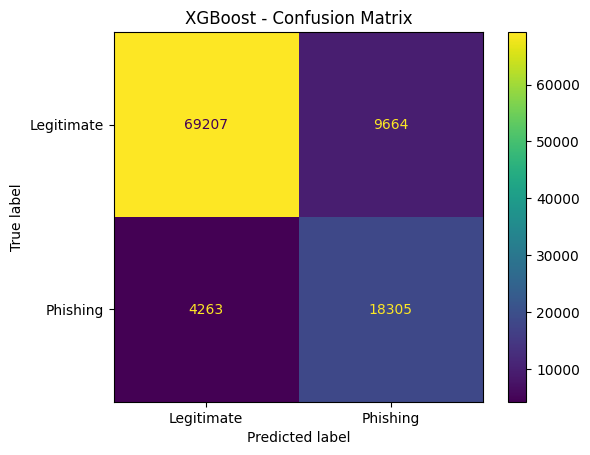

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in models:
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print(cm)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Legitimate', 'Phishing']
    ).plot()

    plt.title(f'{name} - Confusion Matrix')
    plt.show()

In [38]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import pandas as pd

# --------------------------------------------------
# 1. Calculate class imbalance ratio
# --------------------------------------------------

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale Pos Weight:", scale_pos_weight)


# --------------------------------------------------
# 2. Define balanced models
# --------------------------------------------------

rf_model = RandomForestClassifier(
    random_state=22,
    class_weight='balanced',
    n_jobs=-1
)

xgb_model = XGBClassifier(
    random_state=22,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)


# --------------------------------------------------
# 3. Train both models
# --------------------------------------------------

rf_model.fit(X_train, y_train)

xgb_model.fit(X_train, y_train)


# --------------------------------------------------
# 4. Get probability of phishing (class 1)
# --------------------------------------------------

rf_prob = rf_model.predict_proba(X_test)[:, 1]

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]


# --------------------------------------------------
# 5. Test different thresholds
# --------------------------------------------------

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]


def evaluate_thresholds(y_test, y_prob, model_name):

    results = []

    for threshold in thresholds:

        # Probability >= threshold → phishing
        y_pred = (y_prob >= threshold).astype(int)

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(
            y_test,
            y_pred
        ).ravel()

        results.append({
            'Model': model_name,
            'Threshold': threshold,
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1': f1_score(y_test, y_pred),
            'False Positives': fp,
            'False Negatives': fn,
            'True Positives': tp,
            'True Negatives': tn
        })

    return pd.DataFrame(results)


# --------------------------------------------------
# 6. Evaluate both models
# --------------------------------------------------

rf_results = evaluate_thresholds(
    y_test,
    rf_prob,
    "Random Forest"
)

xgb_results = evaluate_thresholds(
    y_test,
    xgb_prob,
    "XGBoost"
)


# --------------------------------------------------
# 7. Combine results
# --------------------------------------------------

threshold_results = pd.concat(
    [rf_results, xgb_results],
    ignore_index=True
)

print(threshold_results.to_string(index=False))

Scale Pos Weight: 3.4233620407718304
        Model  Threshold  Precision   Recall       F1  False Positives  False Negatives  True Positives  True Negatives
Random Forest        0.3   0.679507 0.803527 0.736331             8553             4434           18134           70318
Random Forest        0.4   0.727942 0.766616 0.746779             6466             5267           17301           72405
Random Forest        0.5   0.773761 0.726515 0.749394             4794             6172           16396           74077
Random Forest        0.6   0.826603 0.682072 0.747414             3229             7175           15393           75642
Random Forest        0.7   0.879321 0.624424 0.730269             1934             8476           14092           76937
      XGBoost        0.3   0.491259 0.911468 0.638423            21302             1998           20570           57569
      XGBoost        0.4   0.574144 0.861928 0.689201            14428             3116           19452           64443
   

In [ ]:
# Hyperparameter tuning using Optuna for Random Forest

import pandas as pd
import optuna

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier


# ============================================================
# 1. Load data
# ============================================================

X = pd.read_csv('/content/x.csv')
y = pd.read_csv('/content/y.csv')['Label']


# Remove accidentally saved DataFrame index
if 'Unnamed: 0' in X.columns:
    X = X.drop(columns=['Unnamed: 0'])


print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())


# ============================================================
# 2. Train-test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=22,
    stratify=y
)


# ============================================================
# 3. Stratified 3-fold CV
# ============================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=22
)


# ============================================================
# 4. Random Forest - Optuna
# ============================================================

def rf_objective(trial):

    params = {
        'n_estimators': trial.suggest_int(
            'n_estimators', 100, 400
        ),

        'max_depth': trial.suggest_int(
            'max_depth', 5, 30
        ),

        'min_samples_split': trial.suggest_int(
            'min_samples_split', 2, 20
        ),

        'min_samples_leaf': trial.suggest_int(
            'min_samples_leaf', 1, 10
        ),

        'max_features': trial.suggest_categorical(
            'max_features',
            ['sqrt', 'log2']
        ),

        'class_weight': 'balanced',

        'random_state': 22,

        'n_jobs': 1
    }

    model = RandomForestClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=1
    )

    return scores.mean()


rf_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=22)
)

rf_study.optimize(
    rf_objective,
    n_trials=20
)


print("\n==============================")
print("Random Forest Optuna Results")
print("==============================")

print("\nBest CV F1:")
print(rf_study.best_value)

print("\nBest Parameters:")
print(rf_study.best_params)


# ============================================================
# 5. Train best Random Forest
# ============================================================

best_rf = RandomForestClassifier(
    **rf_study.best_params,
    class_weight='balanced',
    random_state=22,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

In [ ]:
# ============================================================
# 6. XGBoost - Optuna
# ============================================================

scale_pos_weight = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

print("\nScale Pos Weight:", scale_pos_weight)


def xgb_objective(trial):

    params = {
        'n_estimators': trial.suggest_int(
            'n_estimators', 100, 400
        ),

        'max_depth': trial.suggest_int(
            'max_depth', 3, 10
        ),

        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.3,
            log=True
        ),

        'min_child_weight': trial.suggest_int(
            'min_child_weight', 1, 10
        ),

        'subsample': trial.suggest_float(
            'subsample', 0.6, 1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree', 0.6, 1.0
        ),

        'gamma': trial.suggest_float(
            'gamma', 0, 0.5
        ),

        'scale_pos_weight': scale_pos_weight,

        'random_state': 22,

        'n_jobs': 1
    }

    model = XGBClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=1
    )

    return scores.mean()


xgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=22)
)

xgb_study.optimize(
    xgb_objective,
    n_trials=20
)


print("\n==============================")
print("XGBoost Optuna Results")
print("==============================")

print("\nBest CV F1:")
print(xgb_study.best_value)

print("\nBest Parameters:")
print(xgb_study.best_params)


# ============================================================
# 7. Train best XGBoost
# ============================================================

best_xgb = XGBClassifier(
    **xgb_study.best_params,
    random_state=22,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

models = [
    ("Optuna Random Forest", best_rf),
    ("Optuna XGBoost", best_xgb)
]

for name, model in models:

    y_pred = model.predict(X_test)

    print("\n" + "=" * 45)
    print(name)
    print("=" * 45)

    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1       :", round(f1_score(y_test, y_pred), 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


#     =============================================
# Optuna Random Forest
# =============================================
# Accuracy : 0.8955
# Precision: 0.7589
# Recall   : 0.7862
# F1       : 0.7723

# Confusion Matrix:
# [[72868  5711]
#  [ 4887 17973]]

# =============================================
# Optuna XGBoost
# =============================================
# Accuracy : 0.9029
# Precision: 0.8687
# Recall   : 0.6706
# F1       : 0.7569

# Confusion Matrix:
# [[76262  2317]
#  [ 7530 15330]]

In [ ]:
# got random forest convenient

Final Random Forest Results
Accuracy : 0.8946
Precision: 0.7515
Recall   : 0.7862
F1       : 0.7684

Confusion Matrix:
[[73003  5868]
 [ 4826 17742]]


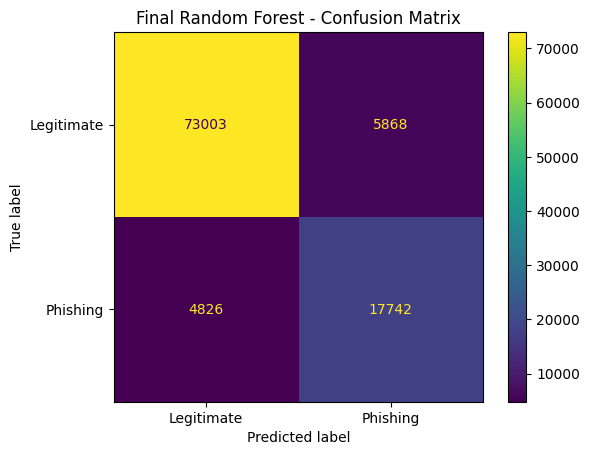

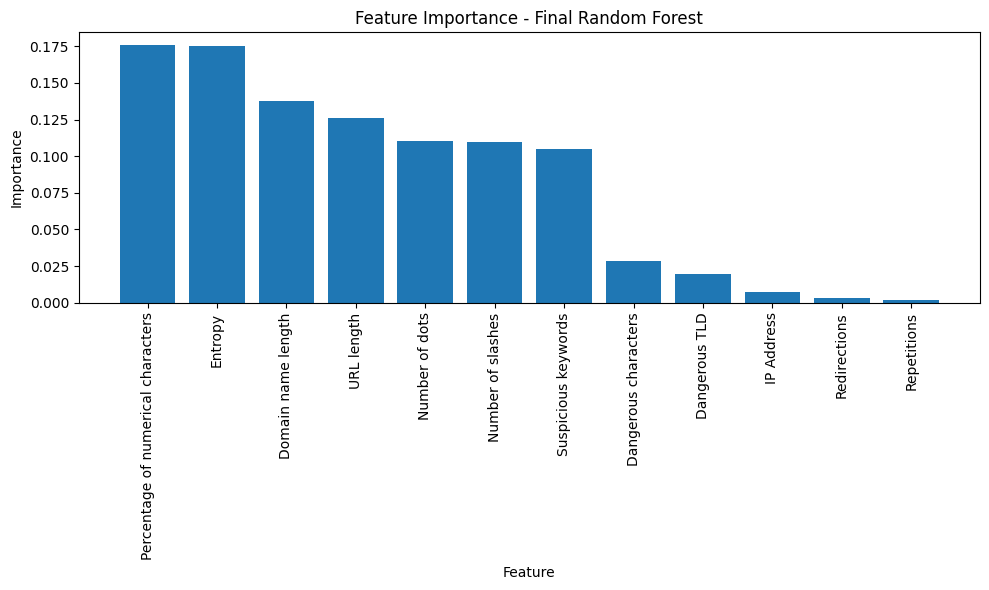

In [24]:


# from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# 1. Create final Random Forest with best Optuna parameters
# ============================================================

final_rf = RandomForestClassifier(
    n_estimators=344,
    max_depth=24,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='log2',
    class_weight='balanced',
    random_state=22,
    n_jobs=-1
)


# ============================================================
# 2. Train on the complete training set
# ============================================================

final_rf.fit(X_train, y_train)


# ============================================================
# 3. Predictions on untouched test set
# ============================================================

y_pred = final_rf.predict(X_test)


# ============================================================
# 4. Calculate metrics
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Final Random Forest Results")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")


# ============================================================
# 5. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Legitimate', 'Phishing']
)

disp.plot()
plt.title("Final Random Forest - Confusion Matrix")
plt.show()


# ============================================================
# 6. Feature Importance
# ============================================================

importances = final_rf.feature_importances_

feature_names = X.columns

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))

plt.bar(
    range(len(feature_names)),
    importances[indices]
)

plt.xticks(
    range(len(feature_names)),
    feature_names[indices],
    rotation=90
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance - Final Random Forest")

plt.tight_layout()
plt.show()